In [1]:
"""
Multi modal Airline Chatbot

What is the chatbot capable of?
- letting you know the ticket prices to places around the world
- If any data isn't available and is provided as input by the user, the bot can save it for future queries
- Bot can make airplane reservations by taking the number of tickets and addint them to booking table
- The response of the chat bot will be relayed in audio
- an image for the place to visit will be displayed to the end user
- After booking attempt, the city image will also display an appropriate message

Technical details:
- Bot can lookup ticket prices from database table and respond to the user
- If any data isn't available and is provided as input by the user, the bot can save it to database and use it for future queries
- Backend booking system that will randomly generate errors for insufficient seat count, flight reschedule, etc. Happy path in this booking system will add an entry into the booking table for the user.
- Text To Speech for chatbot output
- Image generation for the city to visit and image updated with booking outcome message
"""

"\nMulti modal Airline Chatbot\n\nWhat is the chatbot capable of?\n- letting you know the ticket prices to places around the world\n- If any data isn't available and is provided as input by the user, the bot can save it for future queries\n- Bot can make airplane reservations by taking the number of tickets and addint them to booking table\n- The response of the chat bot will be relayed in audio\n- an image for the place to visit will be displayed to the end user\n- After booking attempt, the city image will also display an appropriate message\n\nTechnical details:\n- Bot can lookup ticket prices from database table and respond to the user\n- If any data isn't available and is provided as input by the user, the bot can save it to database and use it for future queries\n- Backend booking system that will randomly generate errors for insufficient seat count, flight reschedule, etc. Happy path in this booking system will add an entry into the booking table for the user.\n- Text To Speech 

In [2]:
#import packages and set up api key
import sys
sys.path.append("..")
import os
from util import check_api_key
from dotenv import load_dotenv
import gradio as gr
from openai import OpenAI
import json
import sqlite3
import base64
from io import BytesIO
from PIL import Image

%load_ext autoreload
%autoreload 2


#DB-backed price lookups now come from AirlineDbUtil's shared module instead of local definitions
from airline_db_util import DB, get_ticket_price, set_ticket_price, set_booking_details, get_booking_details

openai_api_key = check_api_key("openai")

MODEL = "gpt-4.1-mini"
DB = "ticket-prices.db"

openai = OpenAI()

Openai API Key exists and begins sk-proj-


In [3]:
#test data inserted from dictionary
print(get_ticket_price("London"))
print(get_ticket_price("SYDNEY"))
print(get_ticket_price("mumbai"))

DB TOOL CALLED: Getting price for London
Ticket price to London is $799.0
DB TOOL CALLED: Getting price for SYDNEY
Ticket price to SYDNEY is $2999.0
DB TOOL CALLED: Getting price for mumbai
No price data available for this city


In [4]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [5]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}

save_price_function = {
    "name": "set_ticket_price",
        "description": "Set the price of a return ticket to the destination city.",
        "parameters": {
            "type": "object",
            "properties": {
                "destination_city": {
                    "type": "string",
                    "description": "The city that the customer wants to travel to",
                },
                "price" : {
                    "type": "integer",
                    "description": "Ticket price to the city that the customer wants to travel to",
                }
            },
            "required": ["destination_city", "price"],
            "additionalProperties": False
        }
}

book_ticket_function = {
    "name": "set_booking_details",
            "description": "Book flight tickets to the destination city.",
            "parameters": {
                "type": "object",
                "properties": {
                    "destination": {
                        "type": "string",
                        "description": "The city that the customer wants to travel to",
                    },
                    "user" : {
                        "type": "string",
                        "description": "user who is booking the tickets",
                    },
                    "seatCount" : {
                        "type" : "integer",
                        "description" : "Number of tickets the user want to book"
                    }
                },
                "required": ["destination", "user", "seatCount"],
                "additionalProperties": False
            }
}

booking_history_function = {
    "name": "get_booking_details",
            "description": "Get booking history for a user and/ or destination. You have the username from the request and don't have to ask the end user for the user or username again.",
            "parameters": {
                "type": "object",
                "properties": {
                    "destination": {
                        "type": "string",
                        "description": "The city the customer has tickets booked for. This is optional and if not passed in, look up without this argument value.",
                    },
                    "user" : {
                        "type": "string",
                        "description": "user who is booked the tickets. It is derived from the user who logged in.",
                    }
                },
                "required": ["destination", "user"],
                "additionalProperties": False
            }
}

tools = [{"type" : "function", "function" : price_function},{"type" : "function", "function" : save_price_function},
          {"type" : "function", "function" : book_ticket_function}, {"type" : "function", "function" : booking_history_function}]

In [6]:
def artist(promptMessage):
    image_response = openai.images.generate(
        model="gpt-image-1",
        prompt=promptMessage,
        size="1024x1024",
        n=1
    )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

    #prompt = f"An image representing a vacation in {city}, showing its unique tourist attractions in a ghibli style art"

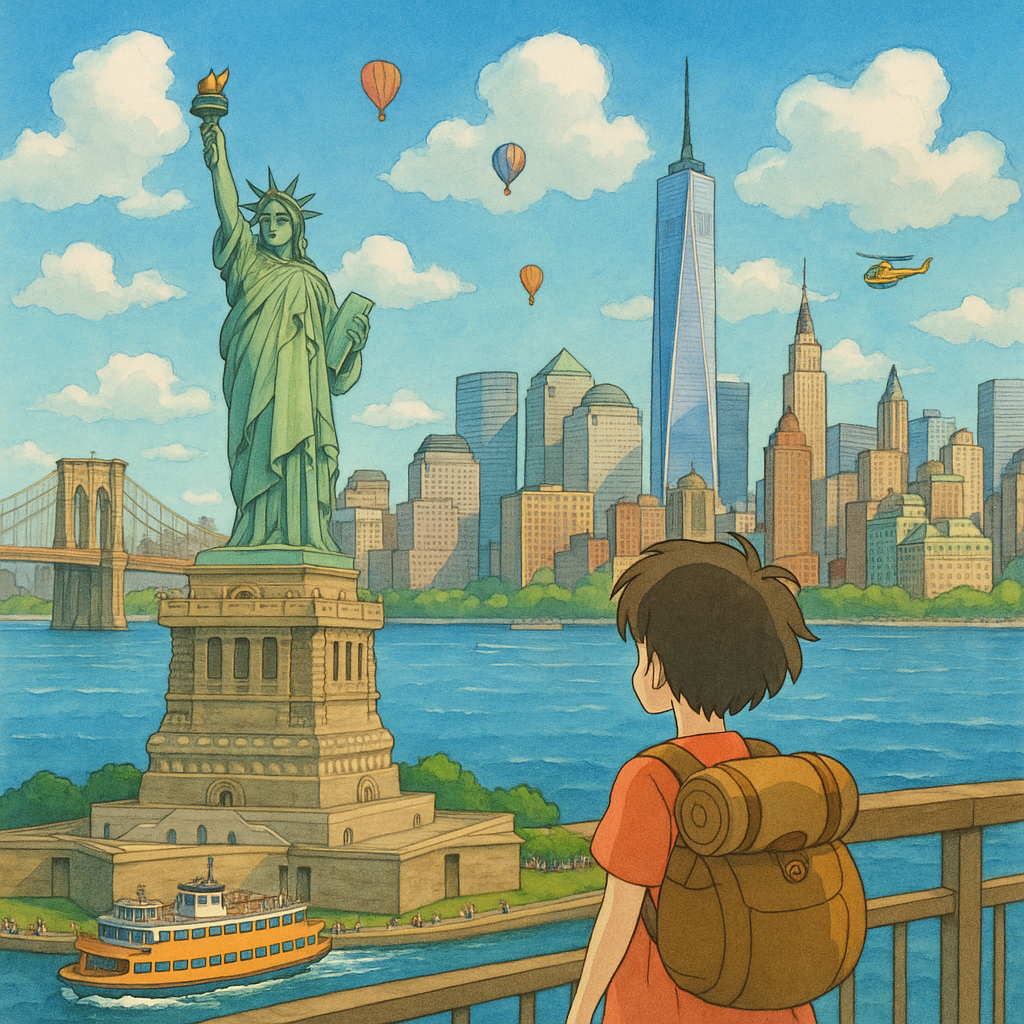

In [22]:
#test image generation
image = artist("An image representing a vacation in New York City, showing its unique tourist attractions in a ghibli style art")
display(image)

In [7]:
def talker(message):
    response = openai.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="coral",
        input=message
    )
    return response.content

In [ ]:
def chat(history, request: gr.Request):
    username = request.username #to be used in booking details call downstream
    print(f"The username from the request is {username}")
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role" : "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None
    ticketBooked = False
    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        if('set_booking_details' in message.tool_calls):
            ticketBooked = True
        response, cities = handle_tool_calls_and_return_cities(message, username)
        messages.append(message)
        messages.extend(response)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    reply = response.choices[0].message.content
    history += [{"role" : "assistant", "content" : reply}]

    voice = talker(reply)

    if cities and  not ticketBooked:
        image = artist(f"An image representing a vacation in {cities[0]}, showing its unique tourist attractions in a tribal art style")
    elif cities and ticketBooked:
        image = artist(f"Generate a image for a tourist who is all set to visit {cities[0]} with the image containing message 'you are all set for your vacation!'")

    return history, voice, image

In [ ]:
#handle tool 

def handle_tool_calls_and_return_cities(message, username):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        print(f"Handle tool call being called for {tool_call.function.name}")
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role" : "tool",
                "content" : price_details,
                "tool_call_id" : tool_call.id
            })
        if tool_call.function.name == "set_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price = arguments.get('price')
            print(f"Calling set_ticket_price with city={city} and price={price}")
            price_details = set_ticket_price(city, price)
            responses.append({
                "role" : "tool",
                "content" : price_details,
                "tool_call_id" : tool_call.id
            })
        if tool_call.function.name == "set_booking_details":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination')
            cities.append(city)
            seatCount = arguments.get('seatCount')
            print(f"Calling set_booking_details with city={city} and seatCount={seatCount} and username = {username}")
            price_details = set_booking_details(username, city, seatCount)
            responses.append({
                "role" : "tool",
                "content" : price_details,
                "tool_call_id" : tool_call.id
            })
        if tool_call.function.name == "get_booking_details":
                    arguments = json.loads(tool_call.function.arguments)
                    city = arguments.get('destination')
                    cities.append(city)
                    print(f"Calling get_booking_details with city={city} and username = {username}")
                    price_details = get_booking_details(username, city)
                    responses.append({
                        "role" : "tool",
                        "content" : price_details,
                        "tool_call_id" : tool_call.id
                    })
    return responses, cities

In [ ]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("adam", "bananas"))

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


The username from the request is adam
Handle tool call being called for get_booking_details
Calling get_booking_details with city=None and username = adam
The username from the request is adam
Handle tool call being called for set_booking_details
Calling set_ticket_price with city=Tokyo and seatCount=1 and username = adam
